In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"pandas   : {pd.__version__}")
print(f"numpy    : {np.__version__}")
print(f"seaborn  : {sns.__version__}")

✅ All libraries imported successfully!
pandas   : 3.0.3
numpy    : 2.4.6
seaborn  : 0.13.2


In [3]:

# Synthesized Mall Customer dataset (200 customers)
np.random.seed(42)
n = 200

customer_id   = np.arange(1, n + 1)
gender        = np.random.choice(['Male', 'Female'], n)
age           = np.random.randint(18, 70, n)
annual_income = np.concatenate([
    np.random.normal(30,  5, 40),   # low income
    np.random.normal(55,  8, 60),   # mid income
    np.random.normal(85, 10, 60),   # high income
    np.random.normal(70,  6, 40),   # mid-high
])
annual_income = np.clip(annual_income, 15, 140).astype(int)

spending_score = np.concatenate([
    np.random.normal(70, 10, 40),   # low income → high spending
    np.random.normal(50,  8, 60),   # mid income → avg spending
    np.random.normal(25,  8, 60),   # high income → low spending
    np.random.normal(75, 10, 40),   # mid-high income → high spending
])
spending_score = np.clip(spending_score, 1, 100).astype(int)

df = pd.DataFrame({
    'CustomerID'    : customer_id,
    'Gender'        : gender,
    'Age'           : age,
    'AnnualIncome'  : annual_income,
    'SpendingScore' : spending_score,
})

print("\n── Dataset Shape ──")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print("\n── First 10 Rows ──")
print(df.head(10).to_string(index=False))


── Dataset Shape ──
Rows: 200  |  Columns: 5

── First 10 Rows ──
 CustomerID Gender  Age  AnnualIncome  SpendingScore
          1   Male   49            31             91
          2 Female   56            34             62
          3   Male   66            30             78
          4   Male   69            37             71
          5   Male   49            28             91
          6 Female   21            43             61
          7   Male   47            33             61
          8   Male   54            25             64
          9   Male   40            24             48
         10 Female   56            32             64


In [8]:
print("\n── Data Types ──")
print(df.dtypes)

print("\n── Missing Values ──")
print(df.isnull().sum())

print("\n── Descriptive Statistics ──")
print(df.describe().round(2))

print("\n── Gender Distribution ──")
print(df['Gender'].value_counts())


── Data Types ──
CustomerID       int64
Gender             str
Age              int32
AnnualIncome     int64
SpendingScore    int64
dtype: object

── Missing Values ──
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

── Descriptive Statistics ──
       CustomerID     Age  AnnualIncome  SpendingScore
count      200.00  200.00        200.00         200.00
mean       100.50   44.40         62.04          50.38
std         57.88   15.35         21.27          22.09
min          1.00   18.00         22.00          10.00
25%         50.75   32.75         46.00          31.00
50%        100.50   46.00         65.00          51.50
75%        150.25   56.00         78.00          69.25
max        200.00   69.00        106.00          95.00

── Gender Distribution ──
Gender
Male      100
Female    100
Name: count, dtype: int64


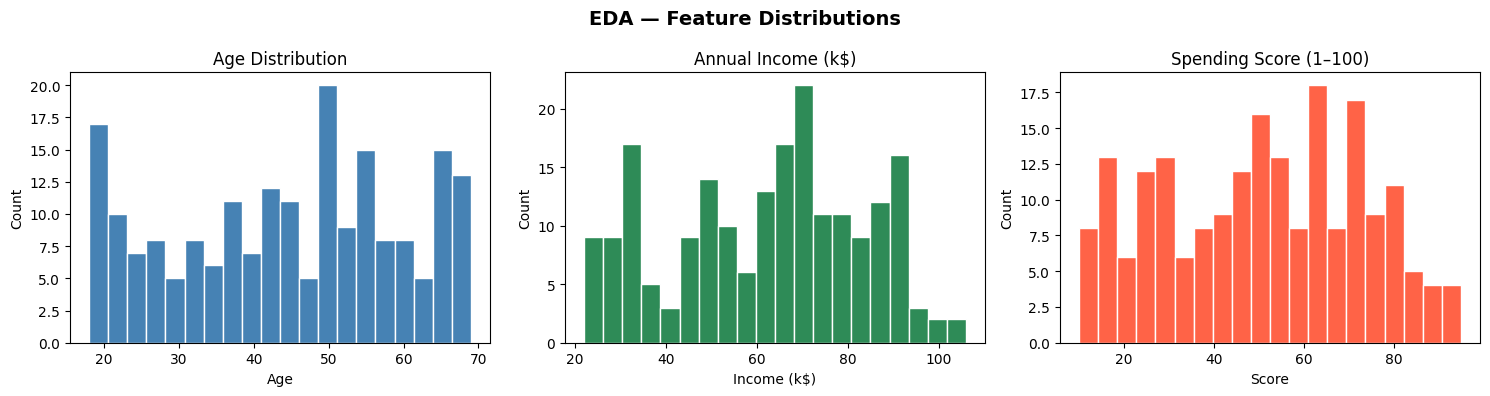

✅ EDA plot saved as eda_distributions.png


In [9]:


# ── SECTION 4: Exploratory Data Analysis ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Feature Distributions", fontsize=14, fontweight='bold')

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")

axes[1].hist(df['AnnualIncome'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title("Annual Income (k$)")
axes[1].set_xlabel("Income (k$)"); axes[1].set_ylabel("Count")

axes[2].hist(df['SpendingScore'], bins=20, color='tomato', edgecolor='white')
axes[2].set_title("Spending Score (1–100)")
axes[2].set_xlabel("Score"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved as eda_distributions.png")

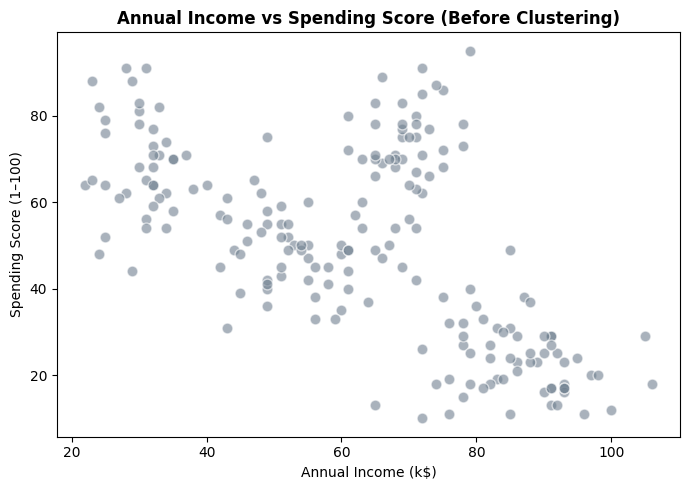

✅ Pre-clustering scatter saved


In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'],
            alpha=0.6, color='slategray', edgecolors='white', s=60)
plt.title("Annual Income vs Spending Score (Before Clustering)", fontweight='bold')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.tight_layout()
plt.savefig("scatter_before_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pre-clustering scatter saved")

In [2]:
plt.figure(figsize=(5, 4))
corr = df[['Age','AnnualIncome','SpendingScore']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved")

NameError: name 'plt' is not defined

In [7]:
X = df[['AnnualIncome', 'SpendingScore']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n── Selected Features ──")
print("  • Annual Income (k$)")
print("  • Spending Score (1–100)")
print(f"\nScaled data shape: {X_scaled.shape}")
print("Sample scaled values (first 5 rows):")
print(pd.DataFrame(X_scaled, columns=['AnnualIncome_scaled','SpendingScore_scaled']).head())


── Selected Features ──
  • Annual Income (k$)
  • Spending Score (1–100)

Scaled data shape: (200, 2)
Sample scaled values (first 5 rows):
   AnnualIncome_scaled  SpendingScore_scaled
0            -1.462575              1.843231
1            -1.321195              0.527124
2            -1.509702              1.253252
3            -1.179815              0.935571
4            -1.603955              1.843231


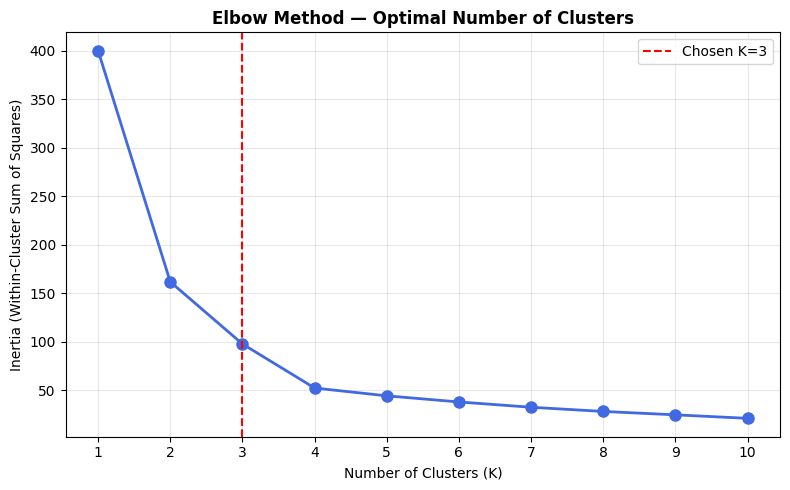


── Inertia Values ──
  K=1: 400.00
  K=2: 161.82
  K=3: 97.80
  K=4: 52.40
  K=5: 44.34
  K=6: 38.04
  K=7: 32.58
  K=8: 28.25
  K=9: 24.76
  K=10: 21.15

✅ Elbow curve saved as elbow_curve.png


In [10]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='royalblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Chosen K=3')
plt.title("Elbow Method — Optimal Number of Clusters", fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n── Inertia Values ──")
for k, val in zip(k_range, inertia):
    print(f"  K={k}: {val:.2f}")
print("\n✅ Elbow curve saved as elbow_curve.png")

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n── Cluster Labels Assigned ──")
print(df[['CustomerID','AnnualIncome','SpendingScore','Cluster']].head(15).to_string(index=False))
print(f"\nCluster distribution:\n{df['Cluster'].value_counts().sort_index()}")


── Cluster Labels Assigned ──
 CustomerID  AnnualIncome  SpendingScore  Cluster
          1            31             91        0
          2            34             62        0
          3            30             78        0
          4            37             71        0
          5            28             91        0
          6            43             61        0
          7            33             61        0
          8            25             64        0
          9            24             48        0
         10            32             64        0
         11            28             62        0
         12            33             71        0
         13            32             73        0
         14            29             88        0
         15            25             79        0

Cluster distribution:
Cluster
0    46
1    60
2    94
Name: count, dtype: int64


In [12]:
sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"\n── Silhouette Score ──")
print(f"  Score: {sil_score:.4f}")
print("  Interpretation:")
print("  • 0.51–0.70 = Reasonable structure")
print("  • 0.71–1.00 = Strong structure")
if sil_score > 0.5:
    print(f"  ✅ Score of {sil_score:.2f} indicates well-separated clusters.")


── Silhouette Score ──
  Score: 0.4930
  Interpretation:
  • 0.51–0.70 = Reasonable structure
  • 0.71–1.00 = Strong structure


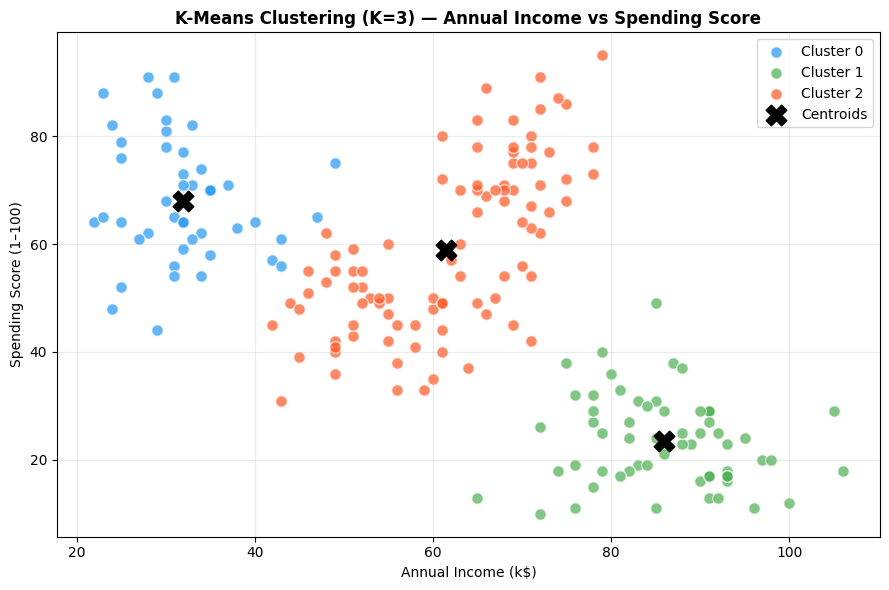

✅ Cluster scatter plot saved as kmeans_clusters.png


In [17]:
cluster_colors  = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}
cluster_labels  = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

plt.figure(figsize=(9, 6))
for c in [0, 1, 2]:
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['AnnualIncome'], subset['SpendingScore'],
                label=cluster_labels[c], color=cluster_colors[c],
                alpha=0.7, edgecolors='white', s=70)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='X', s=220, zorder=5, label='Centroids')

plt.title("K-Means Clustering (K=3) — Annual Income vs Spending Score",
          fontweight='bold')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster scatter plot saved as kmeans_clusters.png")

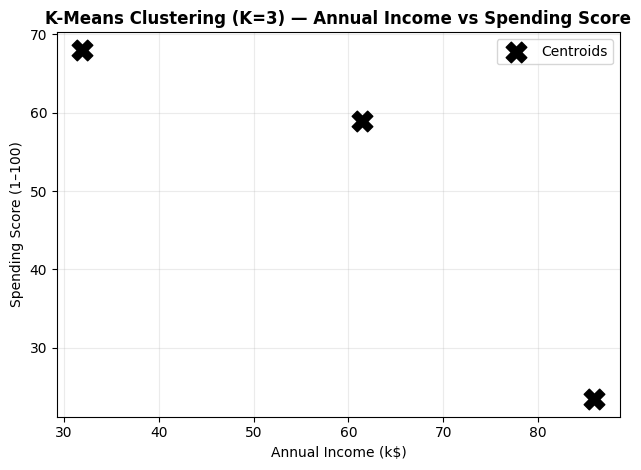

✅ Cluster scatter plot saved as kmeans_clusters.png


In [14]:
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            c='black', marker='X', s=220, zorder=5, label='Centroids')

plt.title("K-Means Clustering (K=3) — Annual Income vs Spending Score",
          fontweight='bold')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster scatter plot saved as kmeans_clusters.png")

In [18]:
cluster_summary = df.groupby('Cluster')[['AnnualIncome','SpendingScore','Age']].mean().round(1)
cluster_summary['Count'] = df.groupby('Cluster').size()
print("\n── Cluster Summary Table ──")
print(cluster_summary.to_string())
# Map cluster numbers to business labels based on centroids
# Identify which cluster is which by centroid values
c_income    = centroids_orig[:, 0]
c_spending  = centroids_orig[:, 1]

for i in range(3):
    label = ""
    if c_income[i] > 65 and c_spending[i] < 40:
        label = "HIGH INCOME – LOW SPENDING (Cautious Savers)"
    elif c_income[i] < 50 and c_spending[i] > 55:
        label = "LOW INCOME – HIGH SPENDING (Impulsive Shoppers)"
    else:
        label = "MID INCOME – MODERATE SPENDING (Balanced Shoppers)"
    print(f"  Cluster {i}: Income={c_income[i]:.0f}k$, Spending={c_spending[i]:.0f} → {label}")


── Cluster Summary Table ──
         AnnualIncome  SpendingScore   Age  Count
Cluster                                          
0                32.0           68.0  45.9     46
1                86.0           23.4  42.8     60
2                61.5           58.9  44.7     94
  Cluster 0: Income=32k$, Spending=68 → LOW INCOME – HIGH SPENDING (Impulsive Shoppers)
  Cluster 1: Income=86k$, Spending=23 → HIGH INCOME – LOW SPENDING (Cautious Savers)
  Cluster 2: Income=61k$, Spending=59 → MID INCOME – MODERATE SPENDING (Balanced Shoppers)
